# 11 - Subgroup Performance and Fairness Audit

Purpose:

- For both the screening and enhanced PCOS models, reproduce the train/test split (random_state=42, test_size=0.25, stratify=y) and predict on the holdout at the threshold stored on the artifact.
- Stratify the holdout by age band (`<25`, `25-34`, `35+`) and BMI category (`underweight`, `normal`, `overweight`, `obese`).
- Within each subgroup, report `n_in_subgroup`, `n_positive`, `n_negative`, `recall`, `specificity`, `PPV`, `NPV` with 1000-bootstrap 95% confidence intervals (stratified by class, clamped to [0, 1]).
- Summarise the **max recall gap** (max minus min subgroup recall) per axis, per model.

Motivation: subgroup performance audits in clinical AI are recommended by Obermeyer et al. 2019 (*Science*, 366:447-453) - aggregate metrics can hide harms in clinically meaningful subgroups. PCOS itself is age- and BMI-related, so silent performance drops in younger or lean patients would directly translate into missed diagnoses.

Outputs:

- `outputs/metrics/subgroup_performance.json`
- `outputs/metrics/subgroup_performance.csv` (long form)
- `outputs/figures/subgroup_recall_by_age.png`
- `outputs/figures/subgroup_recall_by_bmi.png`

Run after notebooks 02 and 03 (which produce the model artifacts) and after notebook 01 (which writes `outputs/pcos_cleaned.csv`).

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
BOOTSTRAP_N = 1000
CI_ALPHA = 0.05  # two-sided 95% CI
MIN_SUBGROUP_N = 10

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
METRIC_DIR = OUTPUT_DIR / "metrics"

for folder in [OUTPUT_DIR, FIGURE_DIR, MODEL_DIR, METRIC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

CLEANED_CSV = OUTPUT_DIR / "pcos_cleaned.csv"
if not CLEANED_CSV.exists():
    raise FileNotFoundError(
        f"Missing {CLEANED_CSV}. Run notebook 01_pcos_data_audit_and_eda.ipynb first."
    )

TARGET = "pcos_y_n"

MODEL_ARTIFACTS = {
    "screening": MODEL_DIR / "pcos_screening_model.joblib",
    "enhanced": MODEL_DIR / "pcos_enhanced_model.joblib",
}

for name, path in MODEL_ARTIFACTS.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run notebook 02 (screening) and 03 (enhanced) first."
        )

pcos = pd.read_csv(CLEANED_CSV)
print("Cleaned PCOS shape:", pcos.shape)
print("Target balance:")
print(pcos[TARGET].value_counts().sort_index())

Cleaned PCOS shape: (541, 41)
Target balance:
pcos_y_n
0    364
1    177
Name: count, dtype: int64


## Reproduce the Train/Test Split

The artifacts were saved by notebooks 02 and 03 after a split with `random_state=42`, `test_size=0.25`, `stratify=y`. We rebuild the same split here so the holdout indices match what each model was scored on at training time. The split depends only on the feature **count and ordering** via `train_test_split`'s indexing of `X`, so we redo the split per artifact using the features list stored in that artifact.

In [2]:
def reproduce_holdout(artifact, df):
    """Return X_test, y_test, and the row indices of the holdout in the original df."""
    features = artifact["features"]
    X = df[features].copy()
    y = df[TARGET].copy()
    _, X_test, _, y_test = train_test_split(
        X, y,
        test_size=0.25,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    return X_test, y_test, X_test.index

artifacts = {name: joblib.load(path) for name, path in MODEL_ARTIFACTS.items()}
for name, art in artifacts.items():
    print(f"{name}: model={art['model_name']} threshold={art['threshold']} "
          f"features={len(art['features'])}")

# Sanity check: confirm holdout predictions reproduce the stored confusion matrix.
for name, art in artifacts.items():
    X_te, y_te, _ = reproduce_holdout(art, pcos)
    proba = art["model"].predict_proba(X_te)[:, 1]
    pred = (proba >= art["threshold"]).astype(int)
    repro_recall = recall_score(y_te, pred)
    stored_recall = art["metrics"]["recall"]
    assert np.isclose(repro_recall, stored_recall), (
        f"{name}: reproduced recall {repro_recall} != stored {stored_recall}"
    )
    print(f"{name}: reproduced holdout recall {repro_recall:.4f} matches stored {stored_recall:.4f}.")

screening: model=random_forest threshold=0.285 features=13
enhanced: model=random_forest threshold=0.38 features=27
screening: reproduced holdout recall 0.8864 matches stored 0.8864.
enhanced: reproduced holdout recall 0.8864 matches stored 0.8864.


## Define Subgroup Bands

- **Age band**: `<25`, `25-34`, `35+` (using `age_yrs`).
- **BMI category**: `underweight (<18.5)`, `normal (18.5-25)`, `overweight (25-30)`, `obese (>=30)` (using `bmi`).

These bands are not features used at training time - the model sees the raw `age_yrs` and `bmi` values; the bands exist only for stratifying the audit.


In [3]:
AGE_BANDS = ["<25", "25-34", "35+"]
BMI_BANDS = [
    "underweight (<18.5)",
    "normal (18.5-25)",
    "overweight (25-30)",
    "obese (>=30)",
]

def assign_age_band(age):
    if pd.isna(age):
        return None
    if age < 25:
        return "<25"
    if age < 35:
        return "25-34"
    return "35+"

def assign_bmi_band(bmi):
    if pd.isna(bmi):
        return None
    if bmi < 18.5:
        return "underweight (<18.5)"
    if bmi < 25:
        return "normal (18.5-25)"
    if bmi < 30:
        return "overweight (25-30)"
    return "obese (>=30)"

pcos["age_band"] = pcos["age_yrs"].apply(assign_age_band)
pcos["bmi_category"] = pcos["bmi"].apply(assign_bmi_band)

print("Full dataset age band counts:")
print(pcos["age_band"].value_counts().reindex(AGE_BANDS, fill_value=0))
print("\nFull dataset BMI category counts:")
print(pcos["bmi_category"].value_counts().reindex(BMI_BANDS, fill_value=0))

Full dataset age band counts:
age_band
<25       50
25-34    332
35+      159
Name: count, dtype: int64

Full dataset BMI category counts:
bmi_category
underweight (<18.5)     36
normal (18.5-25)       278
overweight (25-30)     184
obese (>=30)            43
Name: count, dtype: int64


## Bootstrap Helpers

For each subgroup we resample with replacement **stratified by true class** within the subgroup so a small subgroup never has a resample with zero positives or zero negatives (when both are present in the original). Each metric is clamped to `[0, 1]` and CIs use the 2.5 / 97.5 percentiles of the bootstrap distribution.

If a subgroup has fewer than 10 samples, or has zero positives, or has zero negatives, we skip bootstrapping and record `"insufficient_n"` for any metric whose denominator is unavailable. Recall needs positives; specificity and NPV need negatives; PPV needs at least one predicted positive.

In [4]:
def _clamp(value):
    return float(np.clip(value, 0.0, 1.0))

def safe_recall(y_true, y_pred):
    if (y_true == 1).sum() == 0:
        return np.nan
    return _clamp(recall_score(y_true, y_pred, zero_division=0))

def safe_specificity(y_true, y_pred):
    if (y_true == 0).sum() == 0:
        return np.nan
    return _clamp(recall_score(y_true, y_pred, pos_label=0, zero_division=0))

def safe_ppv(y_true, y_pred):
    if (y_pred == 1).sum() == 0:
        return np.nan
    return _clamp(precision_score(y_true, y_pred, zero_division=0))

def safe_npv(y_true, y_pred):
    # NPV = TN / (TN + FN); undefined when nothing is predicted negative.
    if (y_pred == 0).sum() == 0:
        return np.nan
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    denom = tn + fn
    if denom == 0:
        return np.nan
    return _clamp(tn / denom)

METRIC_FNS = {
    "recall": safe_recall,
    "specificity": safe_specificity,
    "ppv": safe_ppv,
    "npv": safe_npv,
}

def stratified_bootstrap_indices(y_true, n_boot, rng):
    """Yield index arrays for each bootstrap, resampling positives and negatives separately."""
    pos_idx = np.flatnonzero(y_true == 1)
    neg_idx = np.flatnonzero(y_true == 0)
    for _ in range(n_boot):
        sample_pos = rng.choice(pos_idx, size=len(pos_idx), replace=True) if len(pos_idx) else np.array([], dtype=int)
        sample_neg = rng.choice(neg_idx, size=len(neg_idx), replace=True) if len(neg_idx) else np.array([], dtype=int)
        yield np.concatenate([sample_pos, sample_neg])

def bootstrap_metrics(y_true, y_pred, n_boot=BOOTSTRAP_N, rng=None):
    rng = rng or np.random.default_rng(seed=RANDOM_STATE)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    samples = {m: [] for m in METRIC_FNS}
    for idx in stratified_bootstrap_indices(y_true, n_boot, rng):
        yt = y_true[idx]
        yp = y_pred[idx]
        for m, fn in METRIC_FNS.items():
            samples[m].append(fn(yt, yp))
    cis = {}
    lo_q, hi_q = CI_ALPHA / 2, 1 - CI_ALPHA / 2
    for m, vals in samples.items():
        arr = np.array([v for v in vals if not np.isnan(v)], dtype=float)
        if arr.size == 0:
            cis[m] = (np.nan, np.nan)
        else:
            cis[m] = (
                _clamp(np.quantile(arr, lo_q)),
                _clamp(np.quantile(arr, hi_q)),
            )
    return cis

def subgroup_metrics(y_true, y_pred, rng):
    """Point + CI metrics for one subgroup. Marks CIs 'insufficient_n' when n<10 or a class is missing."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = int(len(y_true))
    n_pos = int((y_true == 1).sum())
    n_neg = int((y_true == 0).sum())

    point = {m: fn(y_true, y_pred) for m, fn in METRIC_FNS.items()}

    insufficient = n < MIN_SUBGROUP_N or n_pos == 0 or n_neg == 0
    if insufficient:
        cis = {m: ("insufficient_n", "insufficient_n") for m in METRIC_FNS}
        note = []
        if n < MIN_SUBGROUP_N:
            note.append(f"n<{MIN_SUBGROUP_N}")
        if n_pos == 0:
            note.append("zero_positives")
        if n_neg == 0:
            note.append("zero_negatives")
        ci_note = ";".join(note)
    else:
        cis = bootstrap_metrics(y_true, y_pred, rng=rng)
        ci_note = None

    record = {
        "n_in_subgroup": n,
        "n_positive": n_pos,
        "n_negative": n_neg,
    }
    for m in METRIC_FNS:
        record[m] = {
            "point": (None if np.isnan(point[m]) else float(point[m])),
            "ci_lo": cis[m][0],
            "ci_hi": cis[m][1],
        }
    if ci_note:
        record["ci_note"] = ci_note
    return record

## Run the Audit

For each model we score the holdout at the artifact's stored threshold, then walk the age and BMI bands and compute the subgroup metrics.

In [5]:
AXIS_DEFINITIONS = [
    ("age_band", AGE_BANDS),
    ("bmi_category", BMI_BANDS),
]

def audit_model(name, artifact, df):
    X_te, y_te, idx = reproduce_holdout(artifact, df)
    proba = artifact["model"].predict_proba(X_te)[:, 1]
    threshold = float(artifact["threshold"])
    pred = (proba >= threshold).astype(int)

    holdout_meta = df.loc[idx, ["age_band", "bmi_category"]].copy()
    holdout_meta["y_true"] = y_te.values
    holdout_meta["y_pred"] = pred

    # One RNG per model so bootstraps within a model are reproducible but independent across models.
    rng = np.random.default_rng(seed=RANDOM_STATE)

    model_block = {
        "model_name": artifact["model_name"],
        "threshold": threshold,
        "holdout_size": int(len(y_te)),
        "axes": {},
    }

    for axis_col, band_order in AXIS_DEFINITIONS:
        axis_block = {}
        for label in band_order:
            mask = holdout_meta[axis_col] == label
            axis_block[label] = subgroup_metrics(
                holdout_meta.loc[mask, "y_true"].values,
                holdout_meta.loc[mask, "y_pred"].values,
                rng=rng,
            )
        recalls = [
            v["recall"]["point"] for v in axis_block.values() if v["recall"]["point"] is not None
        ]
        recall_gap = (max(recalls) - min(recalls)) if len(recalls) >= 2 else None
        axis_block["_summary"] = {
            "max_recall_gap": recall_gap,
            "n_subgroups_with_recall": len(recalls),
        }
        model_block["axes"][axis_col] = axis_block
    return model_block

audit_results = {name: audit_model(name, art, pcos) for name, art in artifacts.items()}

for name, block in audit_results.items():
    print(f"\n== {name} (threshold={block['threshold']}) ==")
    for axis, axis_block in block["axes"].items():
        print(f"  Axis: {axis}")
        for label, rec in axis_block.items():
            if label == "_summary":
                print(f"    -> max_recall_gap: {rec['max_recall_gap']}")
                continue
            r = rec["recall"]["point"]
            note = rec.get("ci_note", "")
            print(
                f"    {label}: n={rec['n_in_subgroup']} "
                f"pos={rec['n_positive']} neg={rec['n_negative']} "
                f"recall={None if r is None else round(r, 3)} {note}"
            )


== screening (threshold=0.285) ==
  Axis: age_band
    <25: n=10 pos=5 neg=5 recall=1.0 
    25-34: n=86 pos=33 neg=53 recall=0.848 
    35+: n=40 pos=6 neg=34 recall=1.0 
    -> max_recall_gap: 0.1515151515151515
  Axis: bmi_category
    underweight (<18.5): n=9 pos=2 neg=7 recall=1.0 n<10
    normal (18.5-25): n=69 pos=20 neg=49 recall=0.75 
    overweight (25-30): n=47 pos=16 neg=31 recall=1.0 
    obese (>=30): n=11 pos=6 neg=5 recall=1.0 
    -> max_recall_gap: 0.25

== enhanced (threshold=0.38) ==
  Axis: age_band
    <25: n=10 pos=5 neg=5 recall=0.8 
    25-34: n=86 pos=33 neg=53 recall=0.879 
    35+: n=40 pos=6 neg=34 recall=1.0 
    -> max_recall_gap: 0.19999999999999996
  Axis: bmi_category
    underweight (<18.5): n=9 pos=2 neg=7 recall=1.0 n<10
    normal (18.5-25): n=69 pos=20 neg=49 recall=0.8 
    overweight (25-30): n=47 pos=16 neg=31 recall=0.938 
    obese (>=30): n=11 pos=6 neg=5 recall=1.0 
    -> max_recall_gap: 0.19999999999999996


## Save the JSON and Long-Form CSV

In [6]:
JSON_PATH = METRIC_DIR / "subgroup_performance.json"
CSV_PATH = METRIC_DIR / "subgroup_performance.csv"
FIG_AGE = FIGURE_DIR / "subgroup_recall_by_age.png"
FIG_BMI = FIGURE_DIR / "subgroup_recall_by_bmi.png"

with open(JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(audit_results, f, indent=2, default=str)
print("Wrote", JSON_PATH)

# Long-form CSV: model, axis, group, metric, point, ci_lo, ci_hi, n
rows = []
for model_name, block in audit_results.items():
    for axis, axis_block in block["axes"].items():
        for label, rec in axis_block.items():
            if label == "_summary":
                rows.append({
                    "model": model_name,
                    "axis": axis,
                    "group": "_summary",
                    "metric": "max_recall_gap",
                    "point": rec["max_recall_gap"],
                    "ci_lo": None,
                    "ci_hi": None,
                    "n": None,
                })
                continue
            for metric in METRIC_FNS:
                entry = rec[metric]
                rows.append({
                    "model": model_name,
                    "axis": axis,
                    "group": label,
                    "metric": metric,
                    "point": entry["point"],
                    "ci_lo": entry["ci_lo"],
                    "ci_hi": entry["ci_hi"],
                    "n": rec["n_in_subgroup"],
                })

long_df = pd.DataFrame(rows)
long_df.to_csv(CSV_PATH, index=False)
print("Wrote", CSV_PATH)
long_df.head(20)

Wrote C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-adecac639bbaeb57e\outputs\metrics\subgroup_performance.json
Wrote C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-adecac639bbaeb57e\outputs\metrics\subgroup_performance.csv


,model,axis,group,metric,point,ci_lo,ci_hi,n
0,screening,age_band,<25,recall,1.000000,1.0,1.0,10.0
1,screening,age_band,<25,specificity,0.800000,0.4,1.0,10.0
2,screening,age_band,<25,ppv,0.833333,0.625,1.0,10.0
3,screening,age_band,<25,npv,1.000000,1.0,1.0,10.0
4,screening,age_band,25-34,recall,0.848485,0.727273,0.969697,86.0
5,screening,age_band,25-34,specificity,0.603774,0.471698,0.735849,86.0
6,screening,age_band,25-34,ppv,0.571429,0.490196,0.675,86.0
7,screening,age_band,25-34,npv,0.864865,0.766649,0.968774,86.0
8,screening,age_band,35+,recall,1.000000,1.0,1.0,40.0
9,screening,age_band,35+,specificity,0.794118,0.647059,0.911765,40.0


## Plot Recall by Subgroup

One figure per stratification axis with both models side-by-side. Error bars are 95% bootstrap CIs; bars marked with `n<10` indicate the subgroup was below the audit threshold (no CI shown).

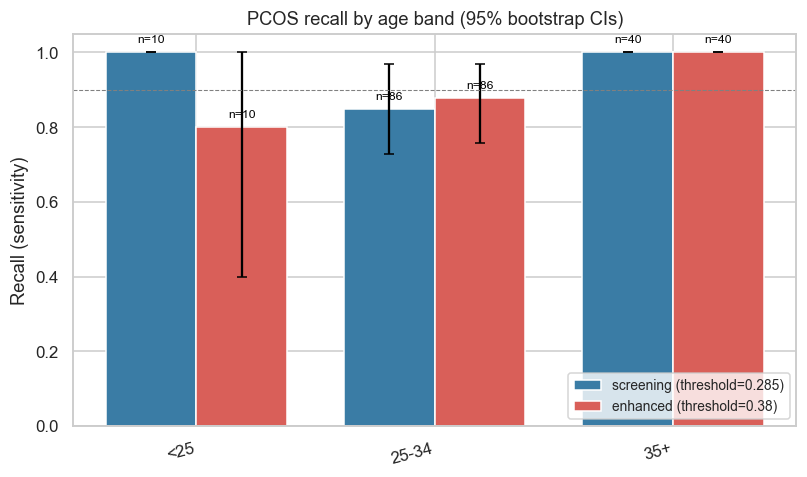

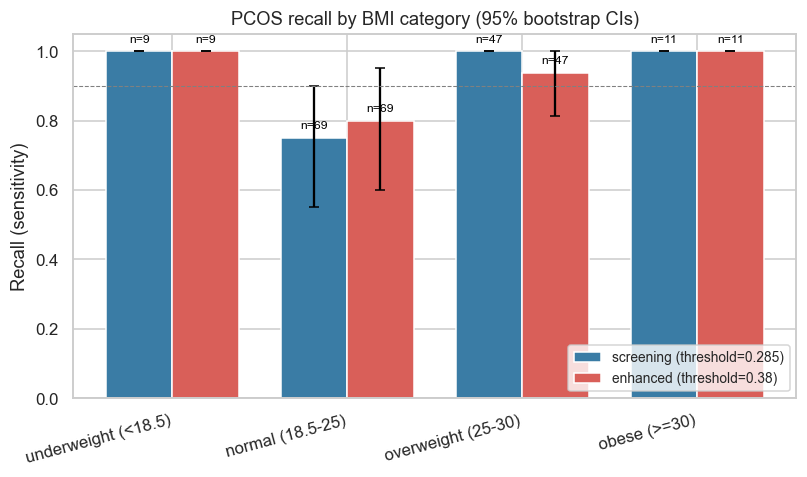

Wrote C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-adecac639bbaeb57e\outputs\figures\subgroup_recall_by_age.png
Wrote C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-adecac639bbaeb57e\outputs\figures\subgroup_recall_by_bmi.png


In [7]:
MODEL_COLORS = {"screening": "#3a7ca5", "enhanced": "#d95f59"}

def plot_recall_axis(axis, band_order, title, path):
    model_names = list(audit_results.keys())
    x = np.arange(len(band_order))
    width = 0.38

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for i, model_name in enumerate(model_names):
        block = audit_results[model_name]["axes"][axis]
        points, lows, highs, notes = [], [], [], []
        for label in band_order:
            rec = block[label]
            p = rec["recall"]["point"]
            lo = rec["recall"]["ci_lo"]
            hi = rec["recall"]["ci_hi"]
            n = rec["n_in_subgroup"]
            insufficient = isinstance(lo, str)
            points.append(np.nan if p is None else p)
            if insufficient or p is None:
                lows.append(0.0)
                highs.append(0.0)
            else:
                lows.append(p - lo)
                highs.append(hi - p)
            notes.append(f"n={n}")

        offset = (i - (len(model_names) - 1) / 2) * width
        heights = [0 if np.isnan(v) else v for v in points]
        ax.bar(
            x + offset,
            heights,
            width=width,
            color=MODEL_COLORS.get(model_name, None),
            label=f"{model_name} (threshold={audit_results[model_name]['threshold']})",
        )
        ax.errorbar(
            x + offset,
            heights,
            yerr=[lows, highs],
            fmt="none",
            ecolor="black",
            capsize=3,
        )
        for xi, note, p in zip(x + offset, notes, points):
            ax.text(
                xi,
                0.02 if (np.isnan(p) or p < 0.08) else p + 0.02,
                note,
                ha="center",
                va="bottom",
                fontsize=8,
                color="black",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(band_order, rotation=15, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Recall (sensitivity)")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=9)
    ax.axhline(0.9, color="grey", linestyle="--", linewidth=0.7)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()

plot_recall_axis(
    "age_band",
    AGE_BANDS,
    "PCOS recall by age band (95% bootstrap CIs)",
    FIG_AGE,
)
plot_recall_axis(
    "bmi_category",
    BMI_BANDS,
    "PCOS recall by BMI category (95% bootstrap CIs)",
    FIG_BMI,
)
print("Wrote", FIG_AGE)
print("Wrote", FIG_BMI)

## Headline Recall Gaps

The max recall gap is the difference between the highest and lowest subgroup recall on that axis. Larger gaps mean the model performs noticeably worse for one subgroup than another - the kind of disparity Obermeyer et al. (2019) flag as the most common form of algorithmic harm in healthcare. Gaps reported here are point estimates only and inherit the holdout's small size, so they should be read as flags for further validation, not final equity statements.

In [8]:
summary_rows = []
for model_name, block in audit_results.items():
    for axis, axis_block in block["axes"].items():
        summary_rows.append({
            "model": model_name,
            "axis": axis,
            "max_recall_gap": axis_block["_summary"]["max_recall_gap"],
            "n_subgroups_with_recall": axis_block["_summary"]["n_subgroups_with_recall"],
        })
summary_df = pd.DataFrame(summary_rows)
summary_df

,model,axis,max_recall_gap,n_subgroups_with_recall
0,screening,age_band,0.151515,3
1,screening,bmi_category,0.250000,4
2,enhanced,age_band,0.200000,3
3,enhanced,bmi_category,0.200000,4


## Output File Assertions

In [9]:
expected_paths = [JSON_PATH, CSV_PATH, FIG_AGE, FIG_BMI]
for p in expected_paths:
    assert p.exists() and p.stat().st_size > 0, f"Missing or empty output: {p}"
    print("OK:", p)
print("All expected fairness-audit outputs exist.")

OK: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-adecac639bbaeb57e\outputs\metrics\subgroup_performance.json
OK: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-adecac639bbaeb57e\outputs\metrics\subgroup_performance.csv
OK: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-adecac639bbaeb57e\outputs\figures\subgroup_recall_by_age.png
OK: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-adecac639bbaeb57e\outputs\figures\subgroup_recall_by_bmi.png
All expected fairness-audit outputs exist.
